### Three Visualisation
- Use sklearn plot_tree for quick visualizations
- Create publication-quality visualzation with dtreeviz
- Calculate and interpret feature importance
- Debug models using visualization

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✓ Libraries loaded!')

✓ Libraries loaded!


In [37]:
#load dataset

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'Dataset: {len(X)} samples, {len(feature_names)} features')
print(f'Classes: {class_names}')

Dataset: 150 samples, 4 features
Classes: ['setosa' 'versicolor' 'virginica']


In [38]:
tree = DecisionTreeClassifier(max_depth=3,random_state=42)
tree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [39]:
train_acc = tree.score(X_train, y_train)
test_acc = tree.score(X_test, y_test)

print(f'Training accuracy: {train_acc:.4f}')
print(f'Test accuracy: {test_acc:.4f}')
print(f'Tree depth: {tree.get_depth()}')
print(f'Number of leaves: {tree.get_n_leaves()}')

Training accuracy: 0.9524
Test accuracy: 1.0000
Tree depth: 3
Number of leaves: 5


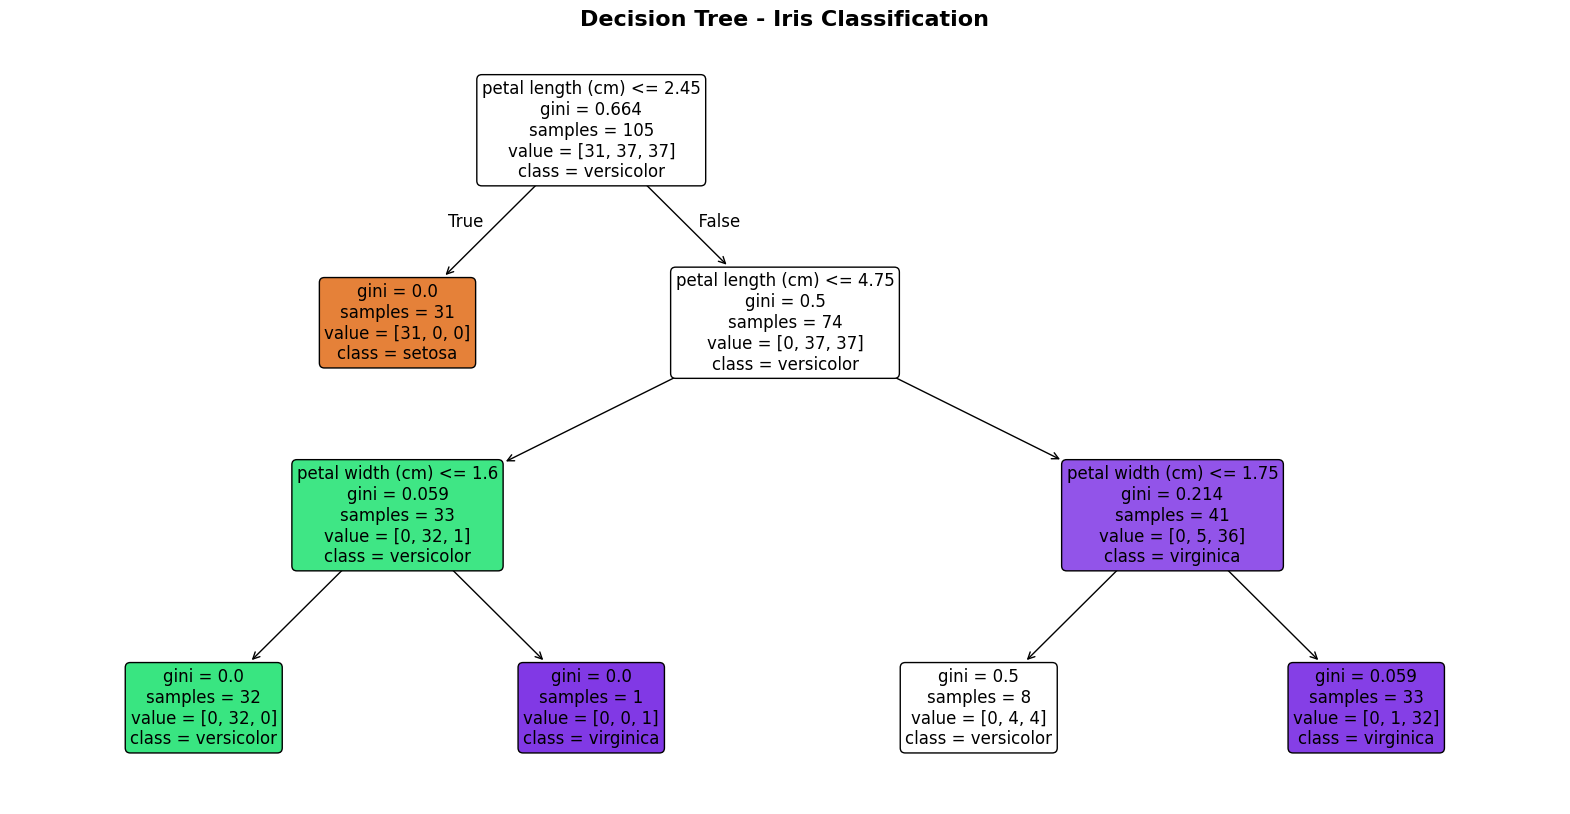

Node interpretation:
- Color: Majority class (darker = more pure)
- gini: Impurity (0 = pure, 0.5 = mixed)
- samples: Training samples in node
- value: [class_0, class_1, class_2] counts


In [40]:
plt.figure(figsize=(20, 10))
plot_tree(tree,
          filled=True,
          feature_names=feature_names,
          class_names=list(class_names),
          rounded=True,
          fontsize=12)
plt.title('Decision Tree - Iris Classification', fontsize=16, fontweight='bold')
plt.show()

print('Node interpretation:')
print('- Color: Majority class (darker = more pure)')
print('- gini: Impurity (0 = pure, 0.5 = mixed)')
print('- samples: Training samples in node')
print('- value: [class_0, class_1, class_2] counts')

In [49]:
#dtreeviz Visualization

#!pip install dtreeviz
#!pip install graphviz

viz_model = model(
    tree,
    X,
    y,
    target_name="iris",
    feature_names=iris.feature_names,
    class_names=list(iris.target_names)
)
viz = viz_model.view()
display(viz)

ExecutableNotFound: failed to execute 'dot', make sure the Graphviz executables are on your systems' PATH

FEATURE IMPORTANCE (Impurity-based)
petal length (cm)        : 0.9251
petal width (cm)         : 0.0749
sepal width (cm)         : 0.0000
sepal length (cm)        : 0.0000


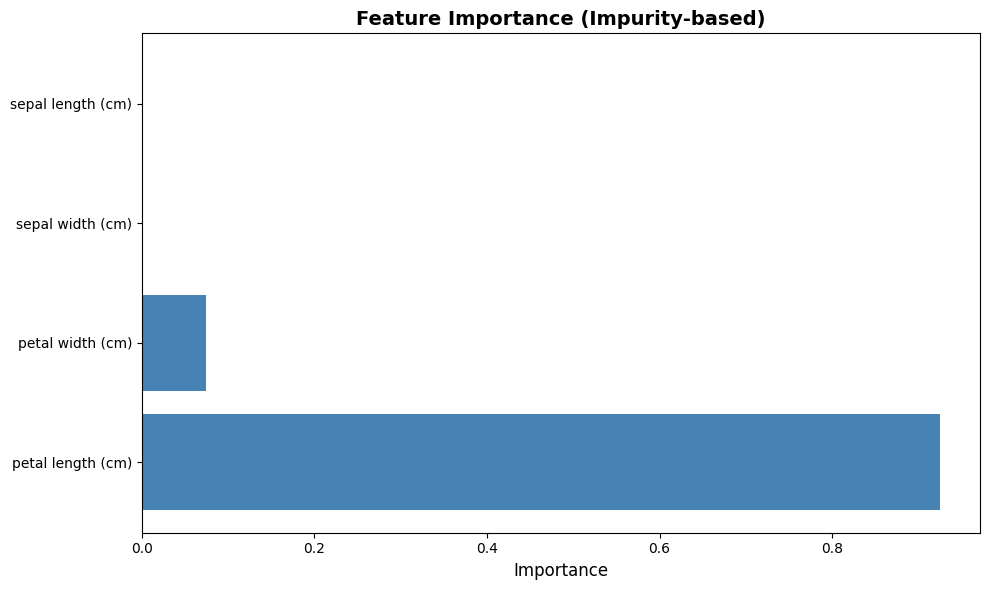

In [50]:
importances = tree.feature_importances_
indices = np.argsort(importances)[::-1]

print('FEATURE IMPORTANCE (Impurity-based)')
print('='*50)
for i in indices:
    print(f'{feature_names[i]:25s}: {importances[i]:.4f}')
print('='*50)

plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices], color='steelblue')
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance (Impurity-based)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [51]:
perm_importance = permutation_importance(tree, X_test, y_test, n_repeats=10, random_state=42)

print('\nPERMUTATION IMPORTANCE (Test Set)')
print('='*50)
for i in np.argsort(perm_importance.importances_mean)[::-1]:
    print(f'{feature_names[i]:25s}: {perm_importance.importances_mean[i]:.4f} ± {perm_importance.importances_std[i]:.4f}')
print('='*50)


PERMUTATION IMPORTANCE (Test Set)
petal length (cm)        : 0.5200 ± 0.0912
petal width (cm)         : 0.3000 ± 0.0318
sepal width (cm)         : 0.0000 ± 0.0000
sepal length (cm)        : 0.0000 ± 0.0000



IMPORTANCE METHOD COMPARISON
          Feature  Impurity  Permutation
petal length (cm)  0.925108         0.52
 petal width (cm)  0.074892         0.30
 sepal width (cm)  0.000000         0.00
sepal length (cm)  0.000000         0.00


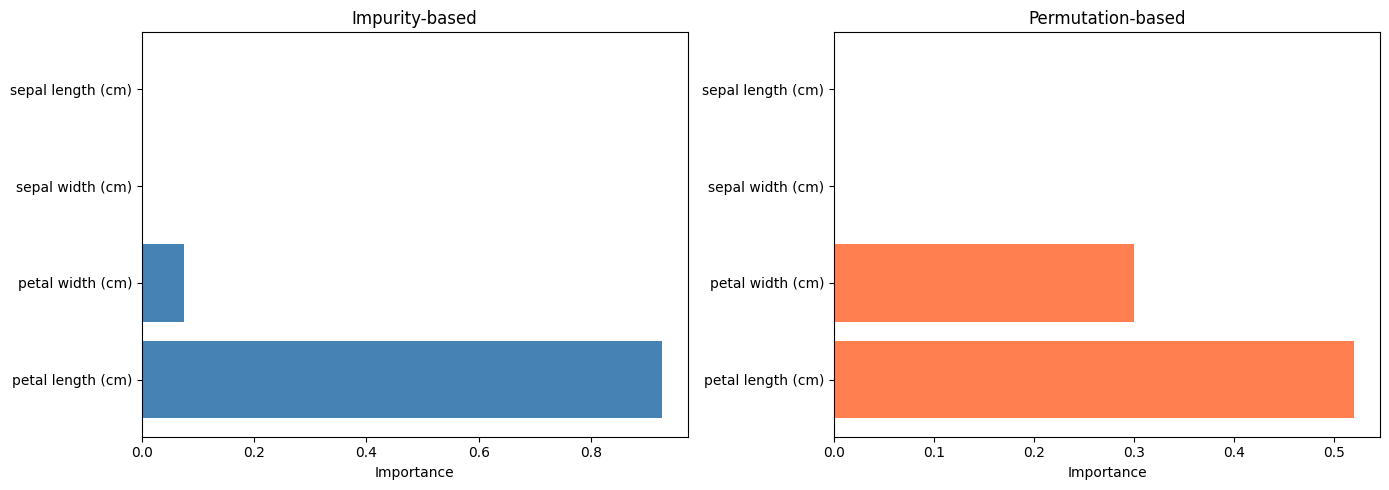

In [52]:
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Impurity': importances,
    'Permutation': perm_importance.importances_mean
})
comparison_df = comparison_df.sort_values('Impurity', ascending=False)

print('\nIMPORTANCE METHOD COMPARISON')
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(comparison_df['Feature'], comparison_df['Impurity'], color='steelblue')
axes[0].set_xlabel('Importance')
axes[0].set_title('Impurity-based')

axes[1].barh(comparison_df['Feature'], comparison_df['Permutation'], color='coral')
axes[1].set_xlabel('Importance')
axes[1].set_title('Permutation-based')

plt.tight_layout()
plt.show()

In [1]:
fgcgfhhj = "Alice"
print(fgcgfhhj)

Alice


In [1]:
fgcgfhhj = "Alice"
print(fgcgfhhj)

Alice


In [1]:
fgcgfhhj = "Alice"
print(fgcgfhhj)

Alice
